# Set-Up
Package and data importing

In [1]:
# essential package imports
import pandas as pd
from data_analysis import combine_pipeline_csvs_to_lexical_master, clean_and_prepare_lexical_df
from series_analysis import run_stationarity_tests, summarize_stationarity, plot_stationarity_heatmap, run_ljung_box_tests, summarize_ljung_box, plot_ljung_box_heatmap, first_difference
from data_analysis import plot_acf_grid
from trend_analysis import run_ols_trend, summarize_ols_trend, plot_ols_trend_grid, run_panel_ols, summarize_panel_ols, plot_panel_coef, run_arimax_trend, summarize_arimax_trend, plot_arimax_fit
from visualization import *

In [2]:
# read in data file as pandas dataframe
# raw_text is excluded via usecols to cut down read time
COLS_TO_LOAD = [
    'utterance_id',
    'speaker_id',
    'timestamp',
    'num_utterances_by_speaker',
    'num_utterances_by_speaker_month',
    'post_depth',
    'score',
    'num_direct_replies',
    'mtld_score',
    'mattr_score',
    'yules_k',
    'zipf_score',
    'aoa_score',
    'nawl_ratio',
    'source_variation',
    'subreddit',
]

METRICS = ['mtld_score', 'mattr_score', 'yules_k', 'zipf_score', 'aoa_score', 'nawl_ratio']

df = pd.read_csv(
    '/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/lexical_master.csv',
    usecols=COLS_TO_LOAD,
)

df = clean_and_prepare_lexical_df(df)

# Temporal Analysis
Examine the trends of each metric—all positively correlated with lexical quality—over time

## Initial Visualization

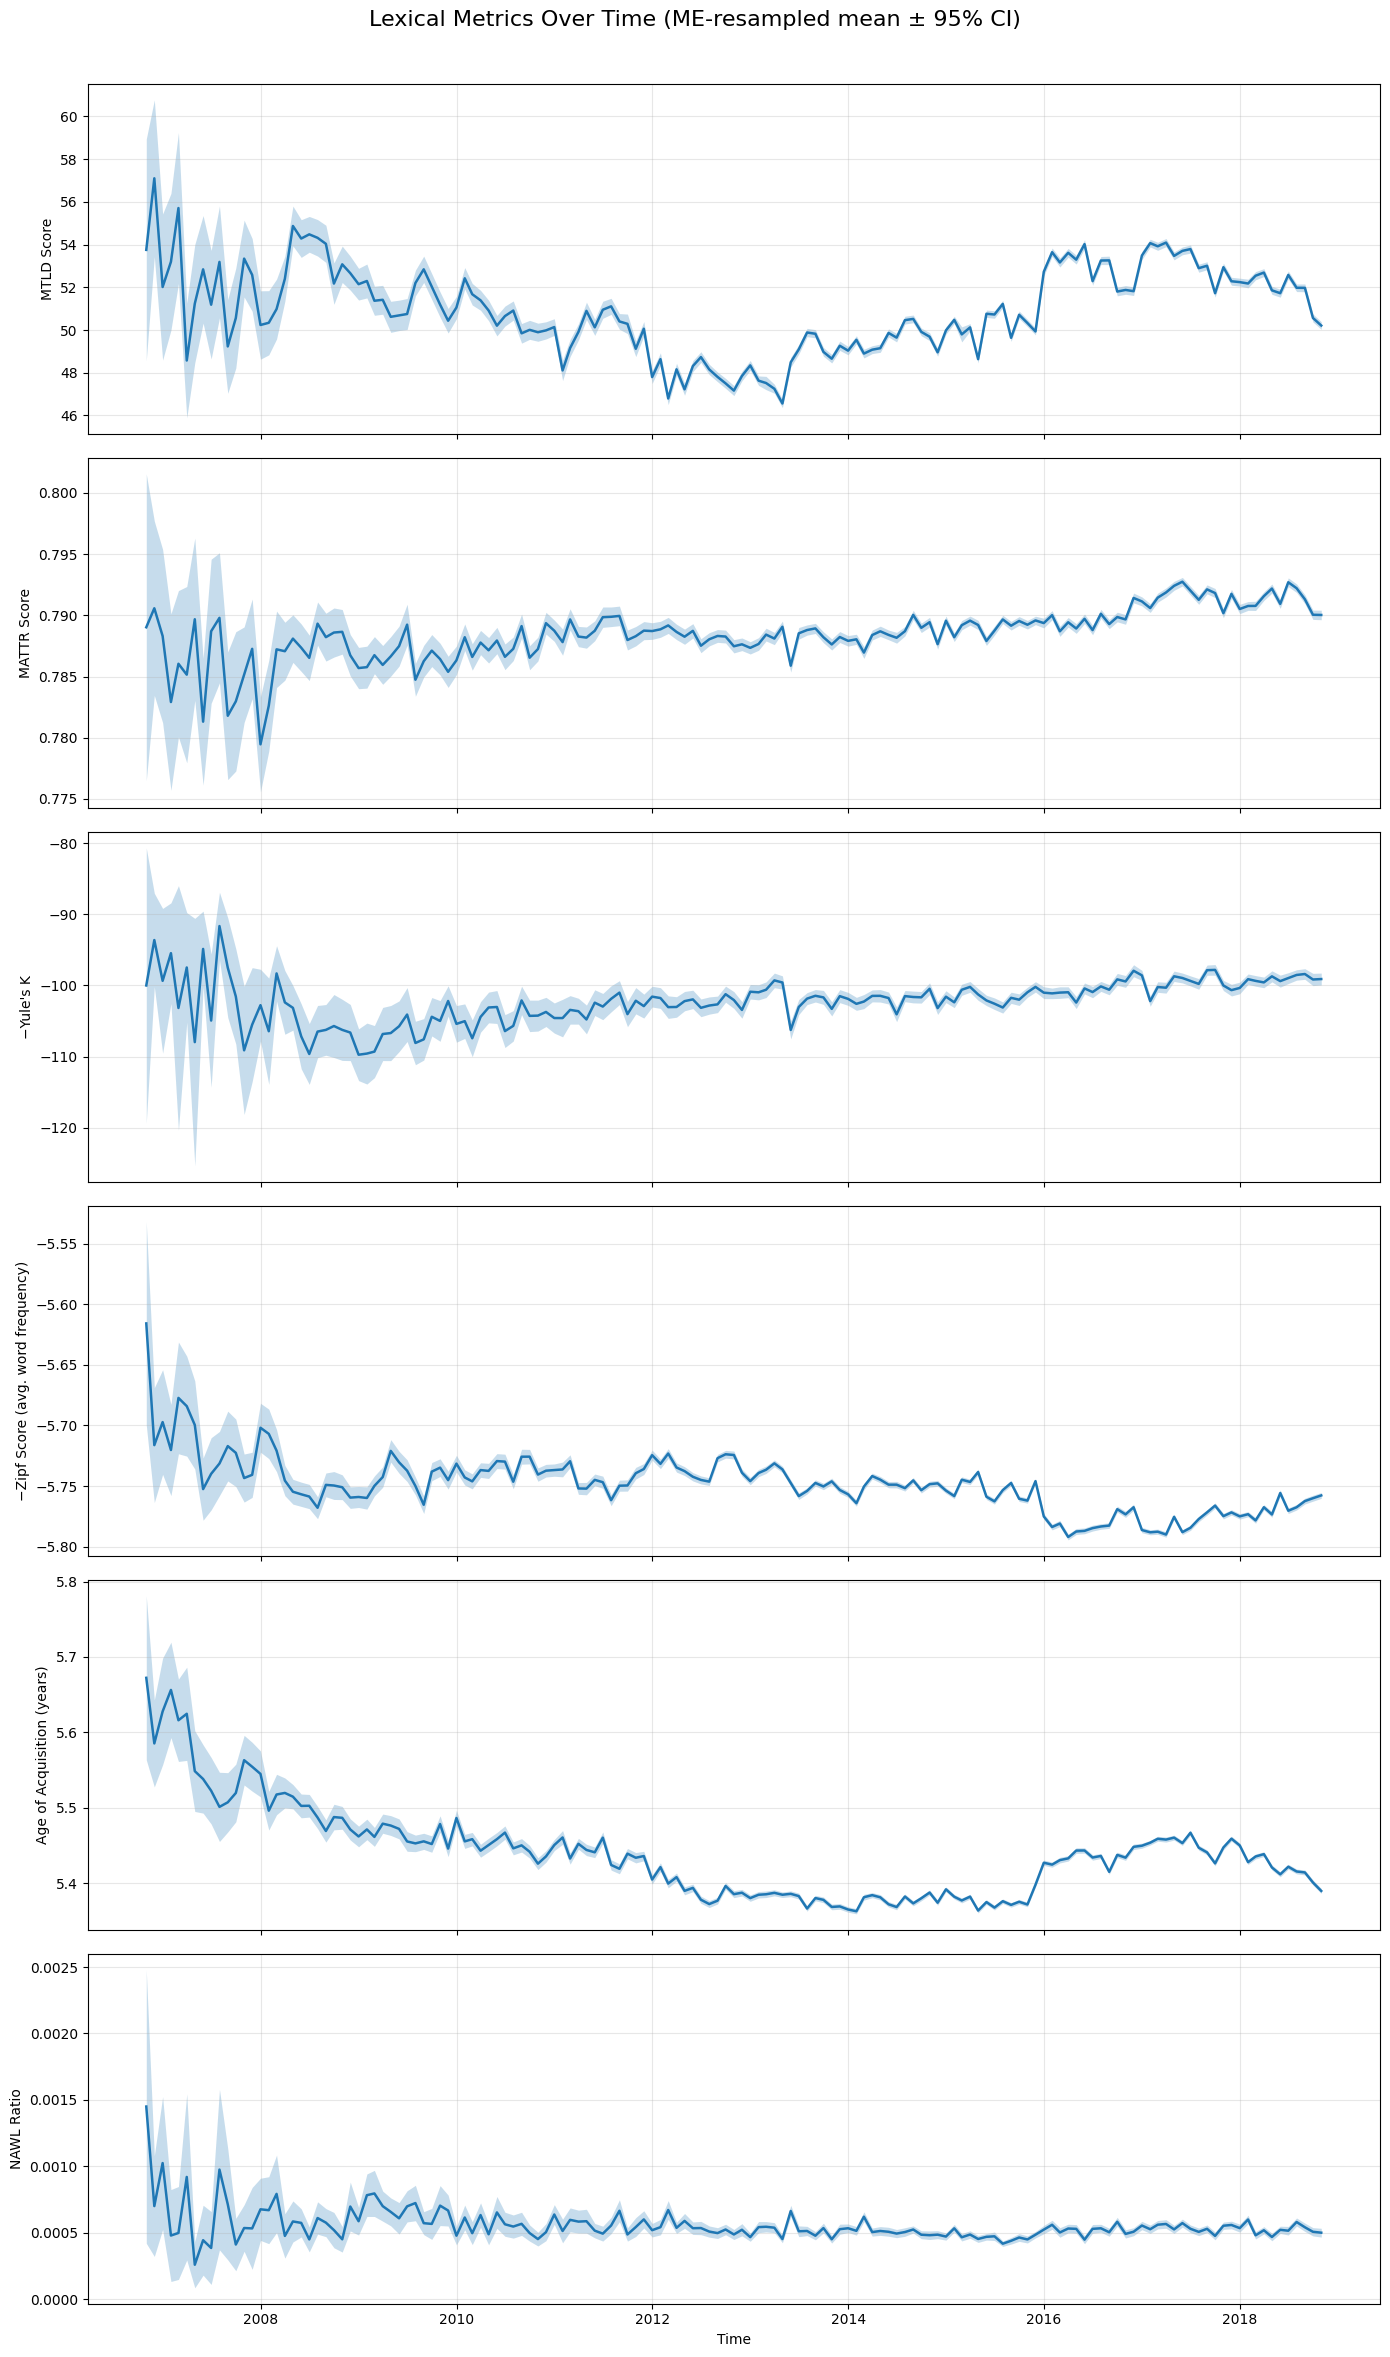

In [3]:
plot_lexical_metrics(df, resample_freq='ME', agg='mean')

/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/visualization.py:240: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled  = series.resample(resample_freq).agg(['mean', 'std', 'count'])


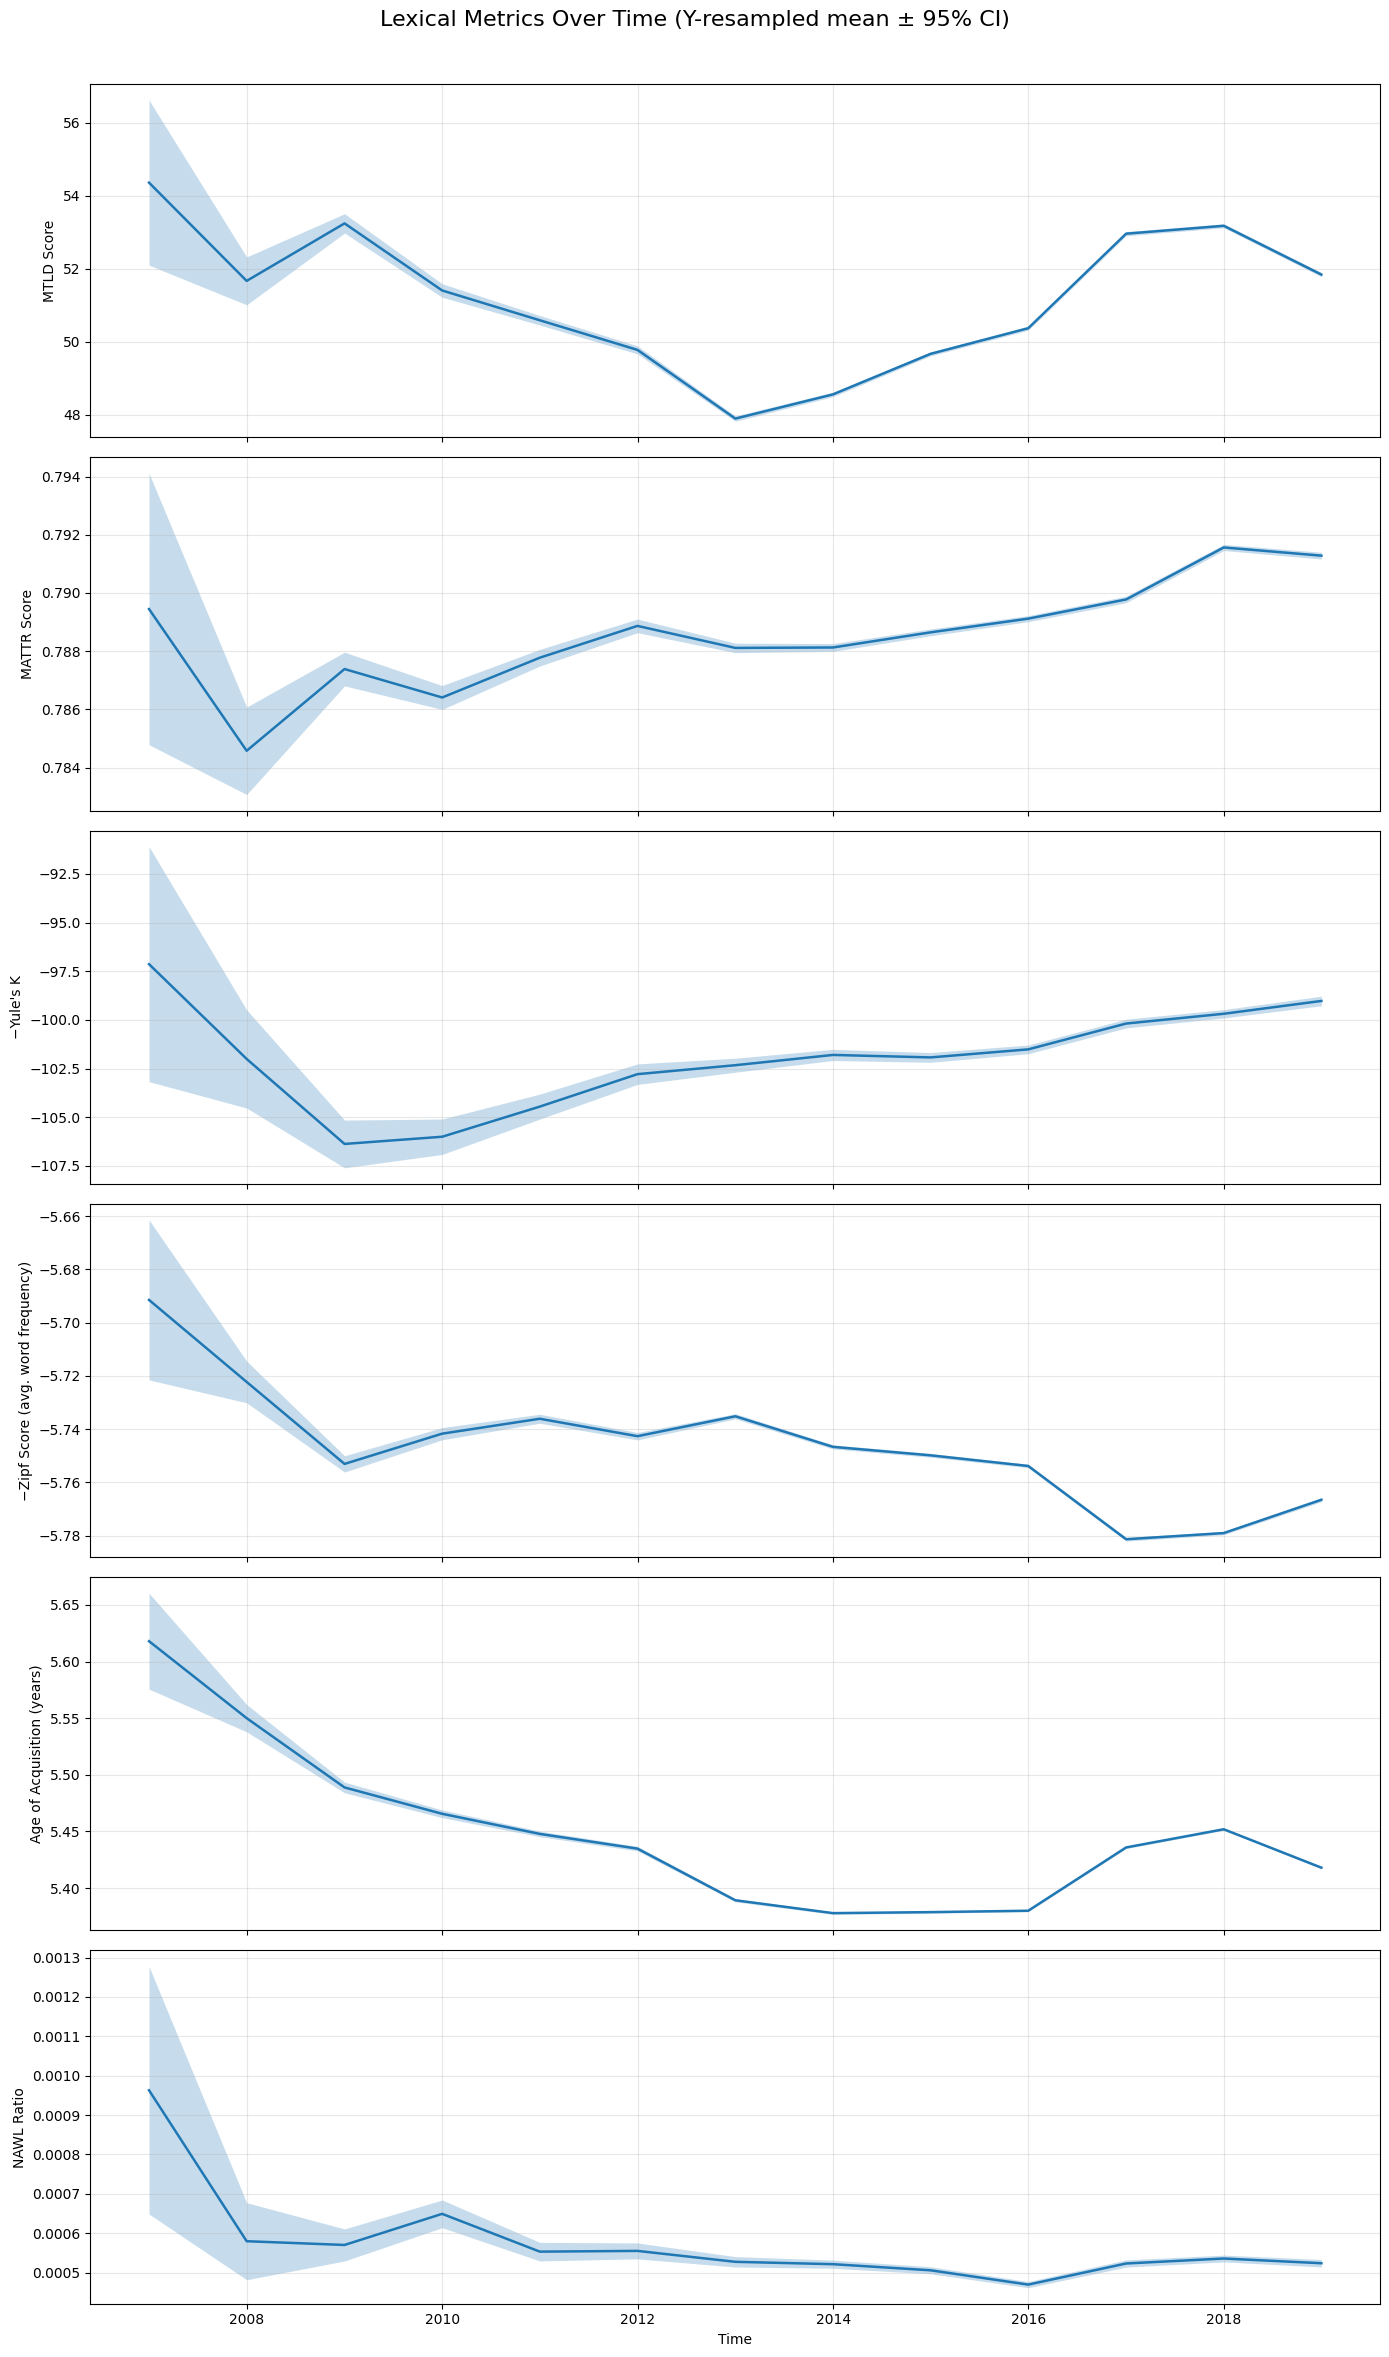

In [4]:
plot_lexical_metrics(df, resample_freq='Y', agg='mean')

## Aggregation
Aggregate to the subreddit-month level

In [5]:
# aggregate and sort
agg = df.groupby(['subreddit', 'year_month'])[METRICS].mean().reset_index()
agg = agg.sort_values(['subreddit', 'year_month'])

In [6]:
# filter subreddits with insufficient time series length
min_obs = 80  # based on DeJong study
counts = agg.groupby('subreddit')['year_month'].count()
valid_subreddits = counts[counts >= min_obs].index
agg = agg[agg['subreddit'].isin(valid_subreddits)]

## Pre-Regression Analysis
Confirm the series is stationary and not autocorrelated, adjusting as necessary

### Stationarity Tests
ADF and KPSS tests

=== Stationarity Test Summary ===
Total (subreddit × metric) series tested: 54

Overall conclusions:
  stationary                               15  (27.8%)
  unit root                                15  (27.8%)
  inconclusive (both reject)               23  (42.6%)
  inconclusive (neither rejects)            1  (1.9%)
  insufficient data                         0  (0.0%)

Breakdown by metric:
  MTLD               → most common: stationary
  MATTR              → most common: inconclusive (both reject)
  Yule's K           → most common: inconclusive (both reject)
  Zipf Score         → most common: unit root
  AoA                → most common: inconclusive (both reject)
  NAWL Ratio         → most common: inconclusive (both reject)


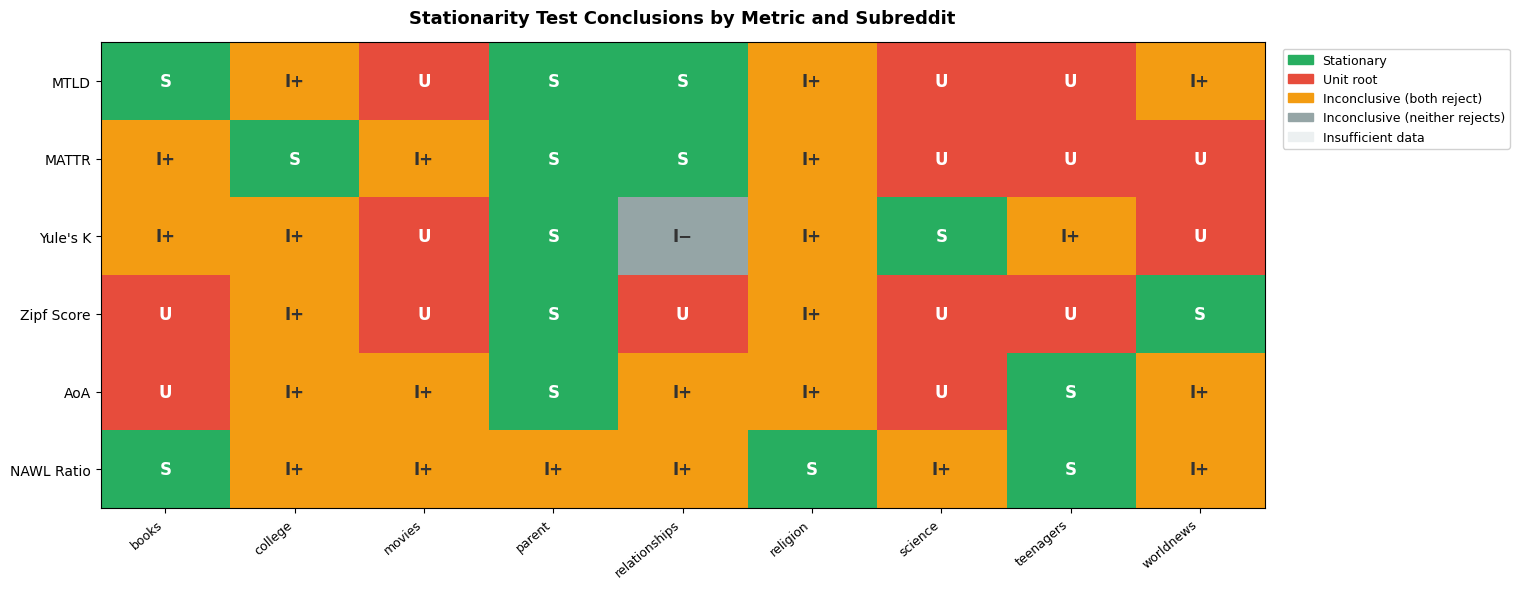

In [7]:
stationarity_results = run_stationarity_tests(agg)
summarize_stationarity(stationarity_results)
plot_stationarity_heatmap(stationarity_results)

### Autocorrelation Tests
Determine if the series is autocorrelated

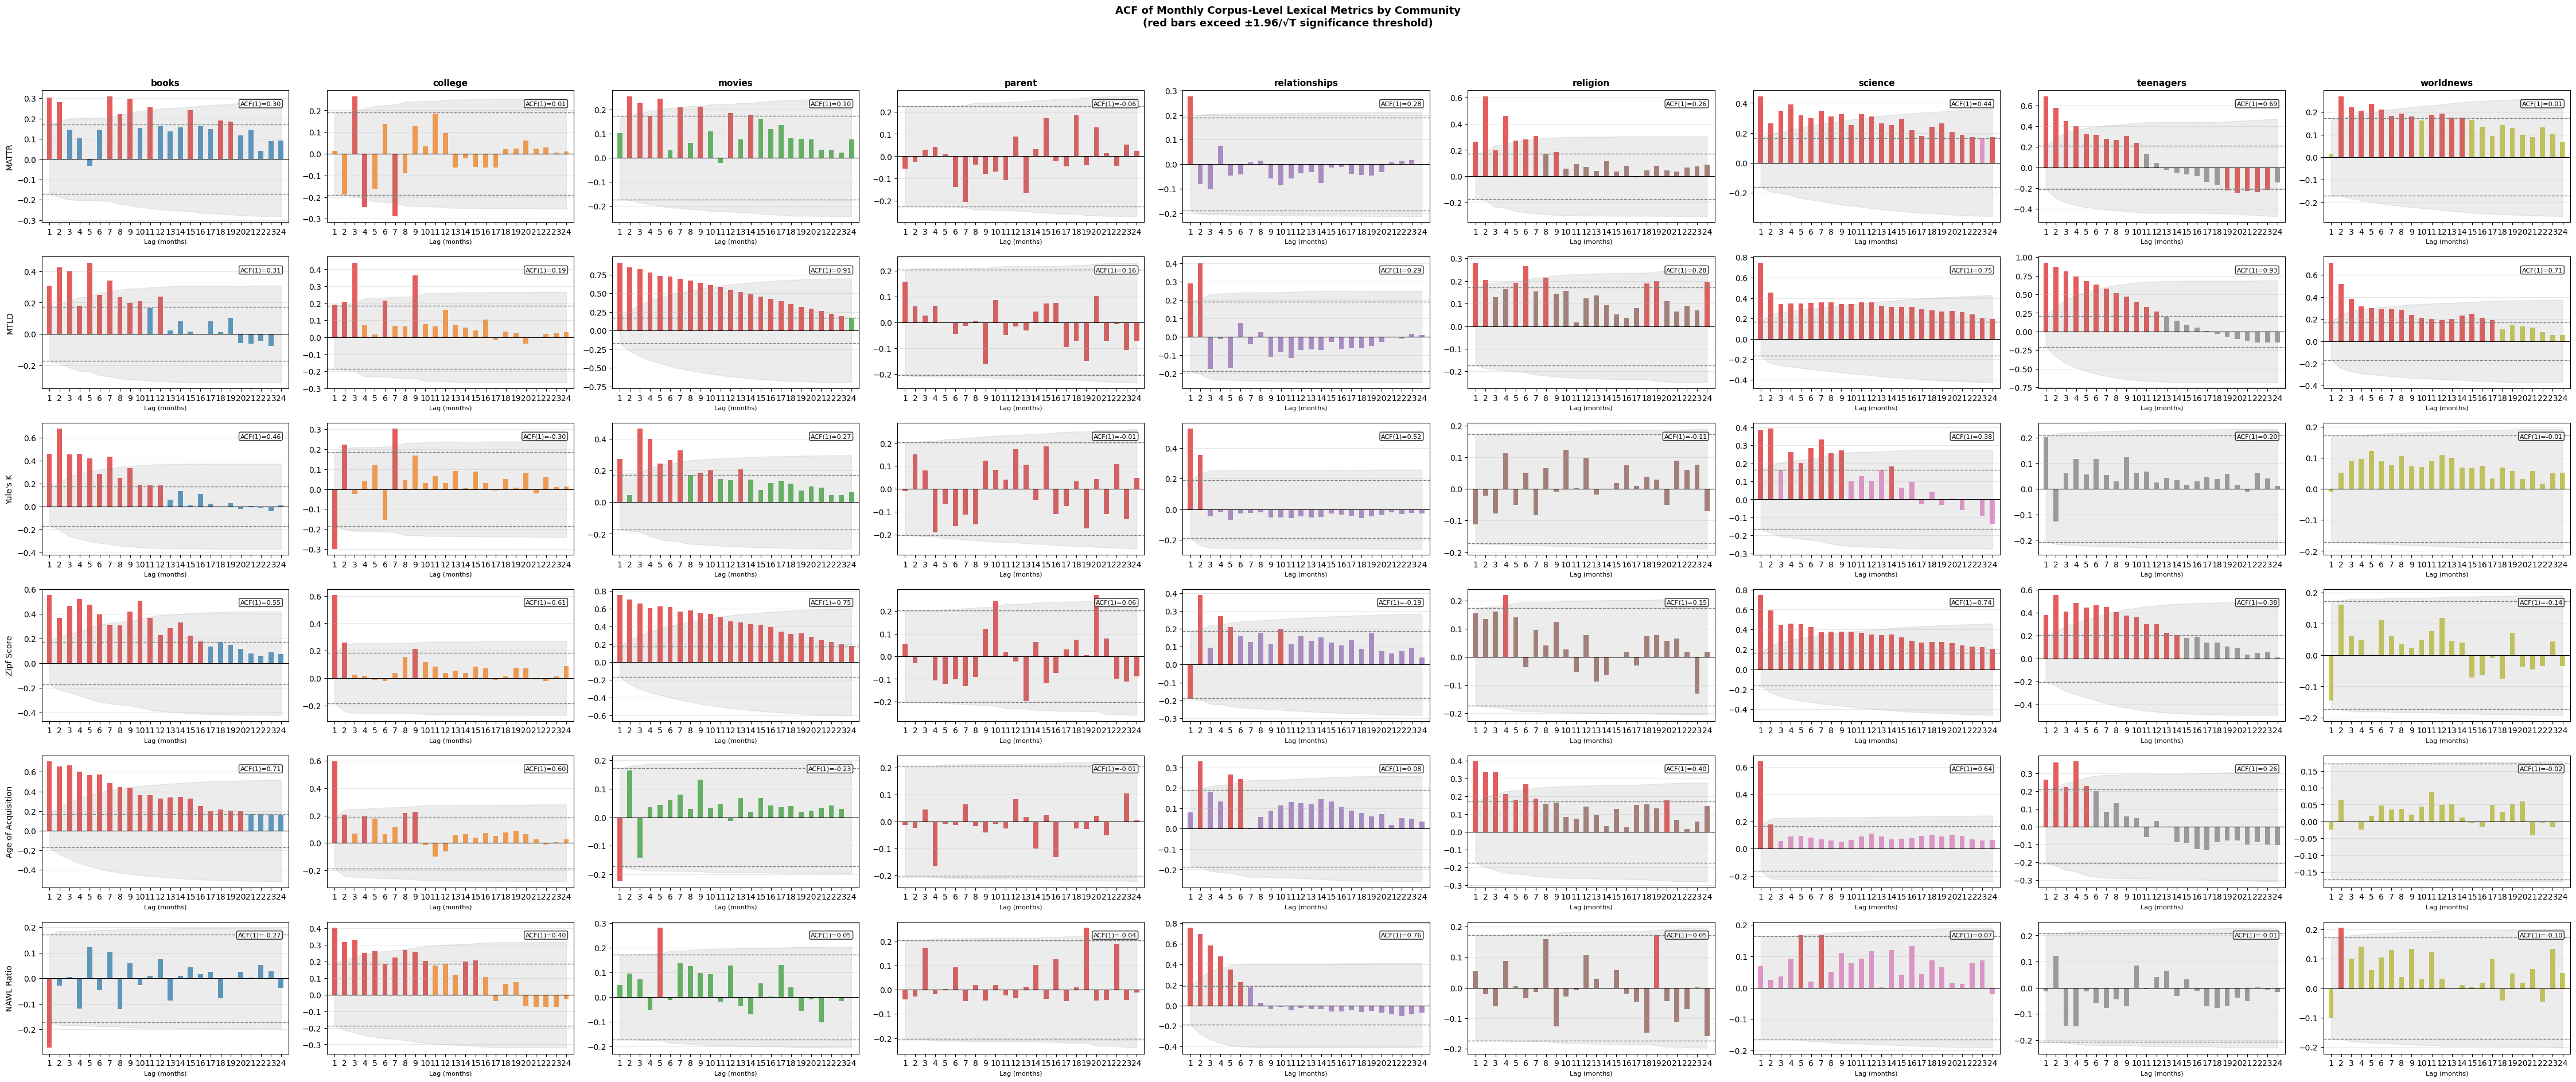

In [8]:
plot_acf_grid(agg, n_lags=24)

=== Ljung-Box Autocorrelation Test Summary ===
Lags tested: h=12, h=6   |   Conclusion based on: h=6
Total (subreddit × metric) series tested: 54

Overall conclusions:
  no autocorrelation          18  (33.3%)
  autocorrelated              36  (66.7%)
  insufficient data            0  (0.0%)

Breakdown by metric:
  MTLD               → most common: autocorrelated
  MATTR              → most common: autocorrelated
  Yule's K           → most common: autocorrelated
  Zipf Score         → most common: autocorrelated
  AoA                → most common: autocorrelated
  NAWL Ratio         → most common: no autocorrelation


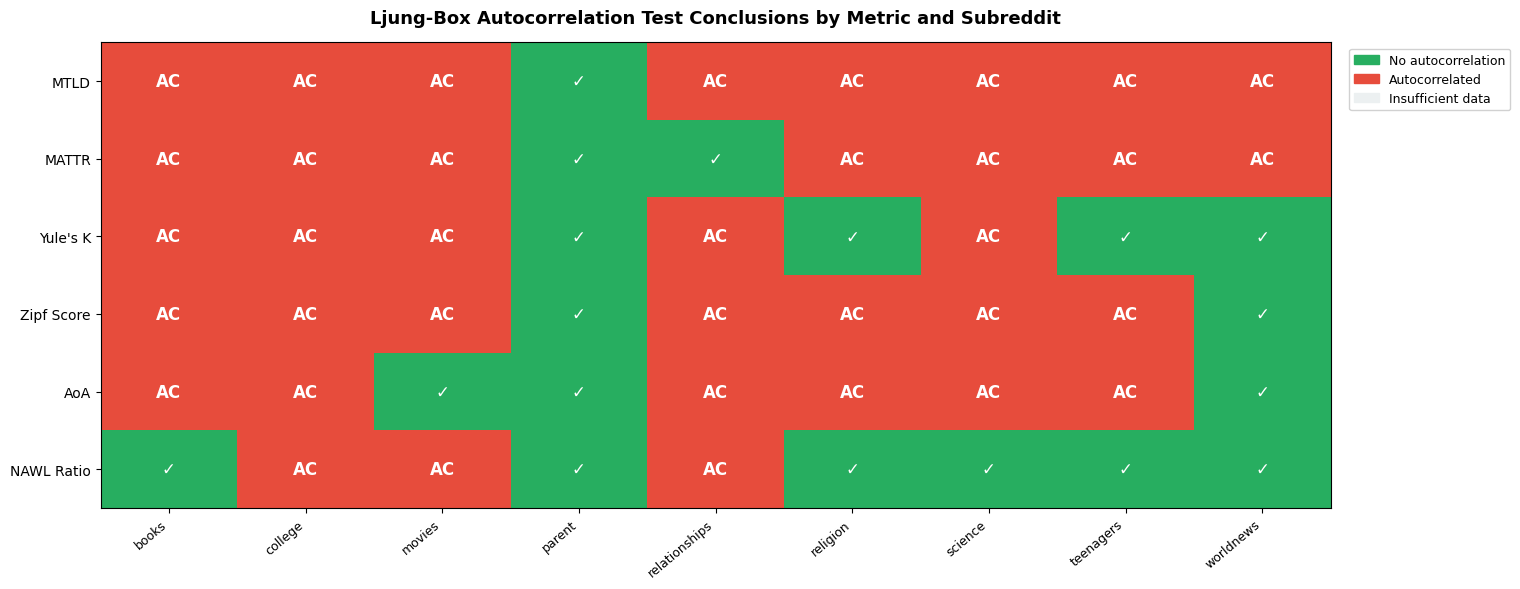

In [9]:
lb_results = run_ljung_box_tests(agg)
summarize_ljung_box(lb_results)
plot_ljung_box_heatmap(lb_results)

### First-Differencing

=== Stationarity Test Summary ===
Total (subreddit × metric) series tested: 54

Overall conclusions:
  stationary                               48  (88.9%)
  unit root                                 0  (0.0%)
  inconclusive (both reject)                6  (11.1%)
  inconclusive (neither rejects)            0  (0.0%)
  insufficient data                         0  (0.0%)

Breakdown by metric:
  MTLD               → most common: stationary
  MATTR              → most common: stationary
  Yule's K           → most common: stationary
  Zipf Score         → most common: stationary
  AoA                → most common: stationary
  NAWL Ratio         → most common: stationary


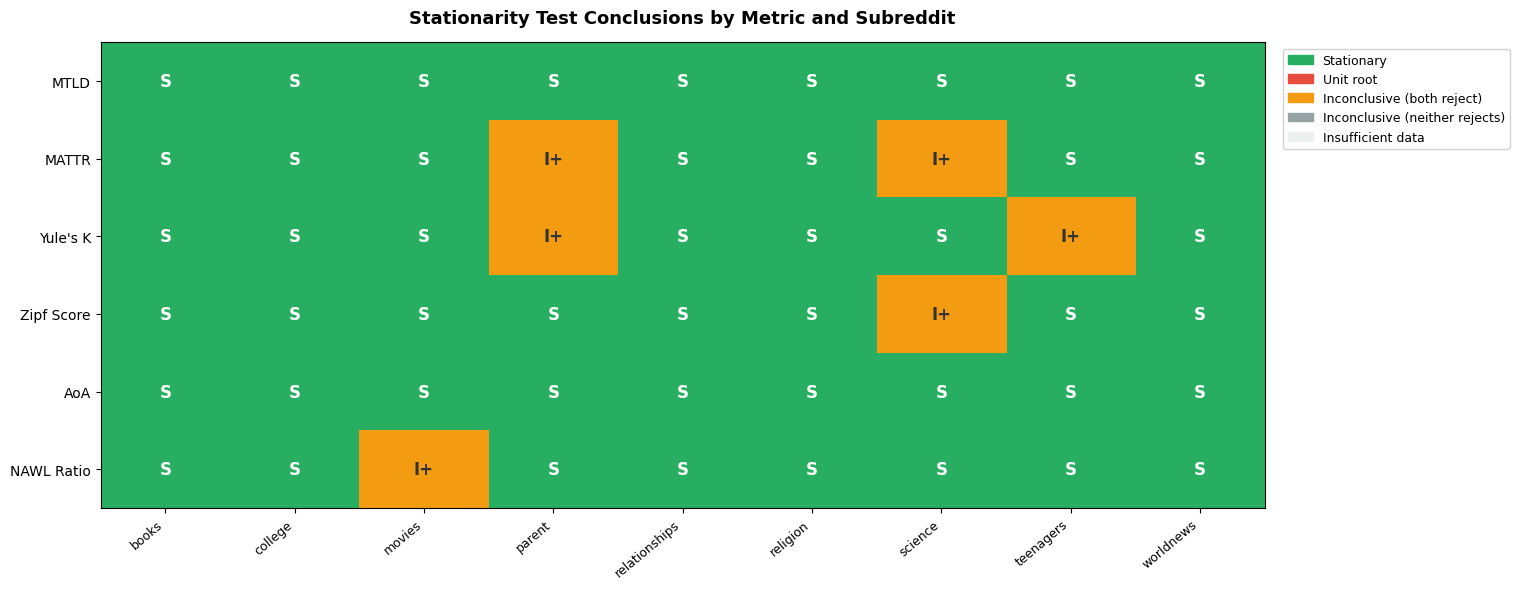

In [10]:
agg_diff = first_difference(agg)
stationarity_results_diff = run_stationarity_tests(agg_diff)   # should now show stationary
summarize_stationarity(stationarity_results_diff)
plot_stationarity_heatmap(stationarity_results_diff)

## Baseline OLS (HAC / Newey-West)

In [11]:
ols_results = run_ols_trend(agg, metrics=METRICS)
summarize_ols_trend(ols_results)

=== Baseline OLS Trend Regression Summary (HAC / Newey-West SEs) ===
Model: y_t = β₀ + β₁·t + ε_t   |   t = integer month index

Total (subreddit × metric) series: 54

Overall conclusions:
  upward trend                   15  (27.8%)
  downward trend                 16  (29.6%)
  no significant trend           23  (42.6%)
  insufficient data               0  (0.0%)

Breakdown by metric:
  MTLD               →  college: ↑ β₁=+0.15578 (SE=0.06642, p=0.0190);  movies: ↑ β₁=+0.30526 (SE=0.05269, p=0.0000);  religion: ↑ β₁=+0.03275 (SE=0.01010, p=0.0012);  science: ↑ β₁=+0.07218 (SE=0.02149, p=0.0008);  teenagers: ↓ β₁=-0.18302 (SE=0.04374, p=0.0000)
  MATTR              →  books: ↓ β₁=-0.00007 (SE=0.00002, p=0.0007);  movies: ↓ β₁=-0.00003 (SE=0.00001, p=0.0267);  religion: ↓ β₁=-0.00011 (SE=0.00003, p=0.0000);  science: ↑ β₁=+0.00005 (SE=0.00001, p=0.0000);  teenagers: ↓ β₁=-0.00007 (SE=0.00003, p=0.0049);  worldnews: ↑ β₁=+0.00006 (SE=0.00001, p=0.0000)
  Yule's K           →  books: ↑ β

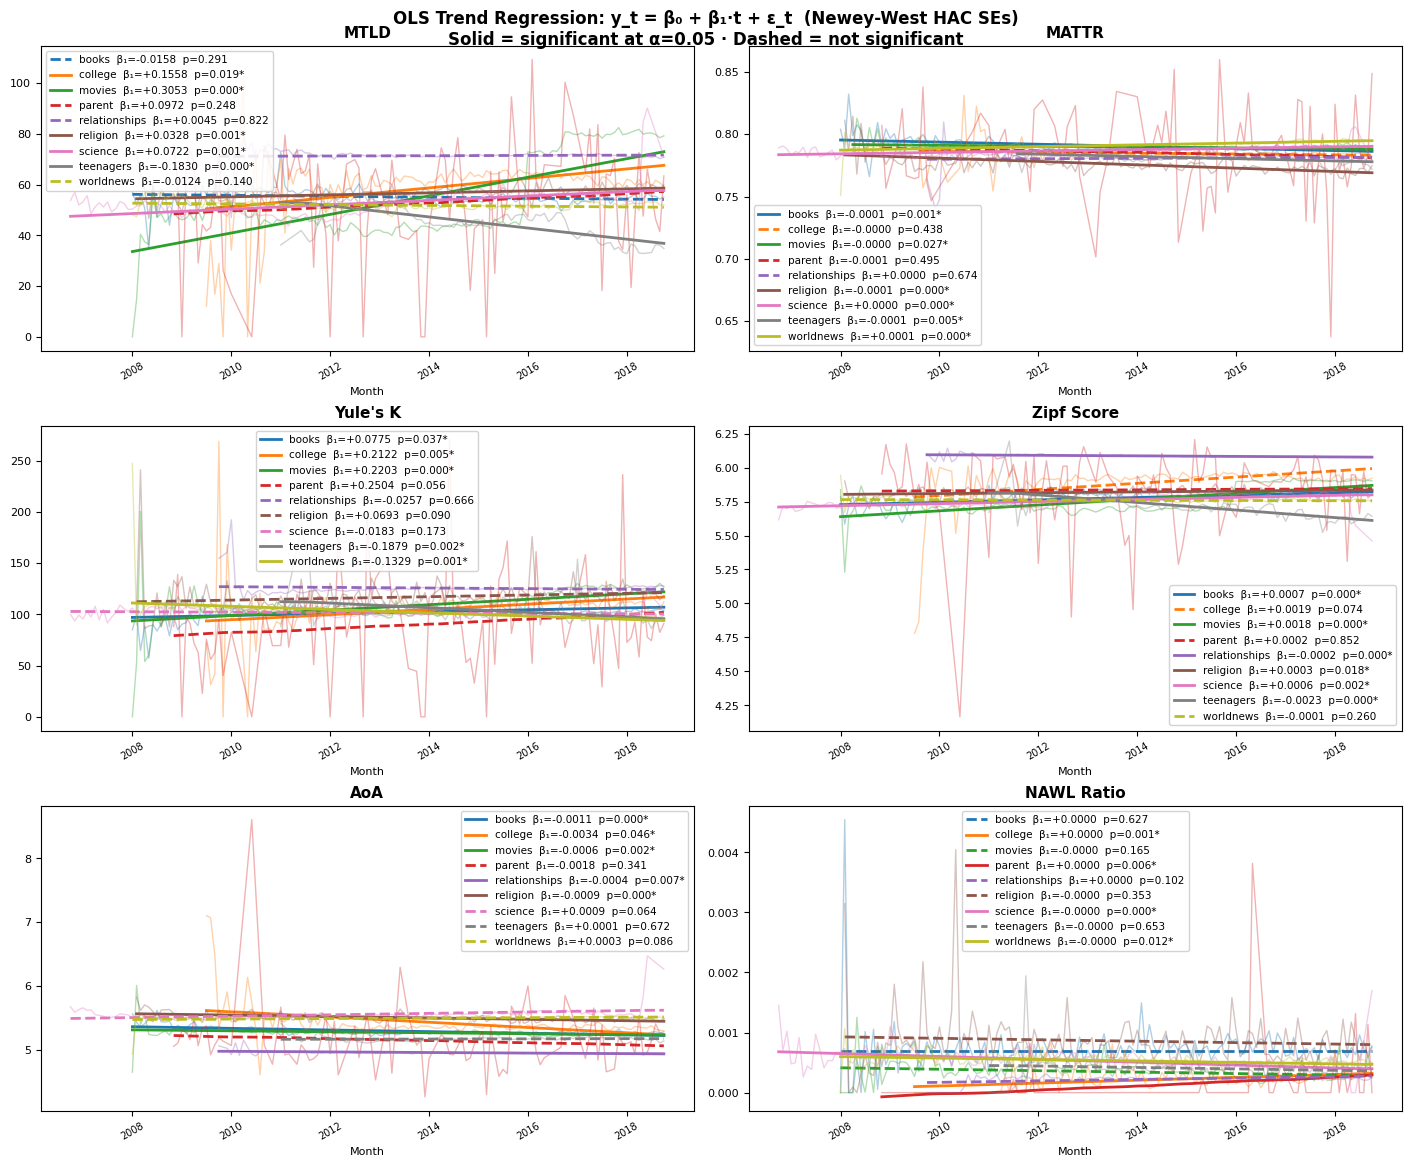

In [12]:
plot_ols_trend_grid(agg, ols_results, metrics=METRICS)

## Panel-Style Regression (HAC / Newey-West)

In [ ]:
panel_results = run_panel_ols(df, metrics=METRICS)
summarize_panel_ols(panel_results)
plot_panel_coef(panel_results, metrics=METRICS)